In [9]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

# Import the modular functions from the simulation script
from basic_repetition_code_simulation import (
    simulate_repetition_code,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Running simulations... (This will take a few seconds)


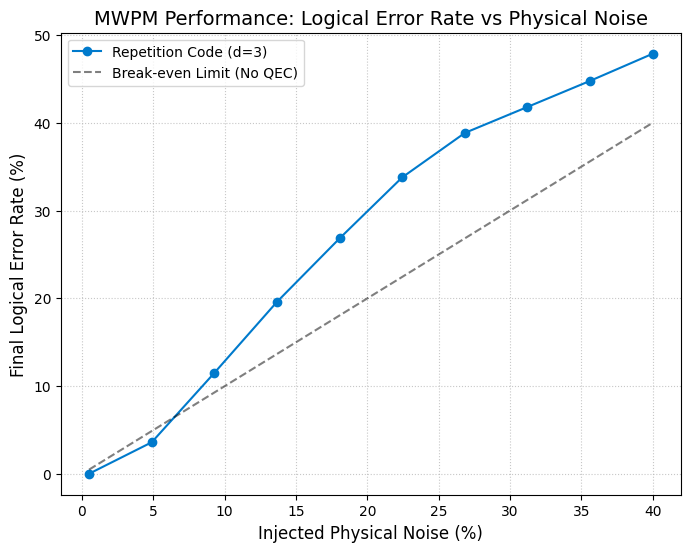

In [ ]:
# Experiment configuration parameters
distance = 3
rounds = 1
num_shots = 10000
min_error_rate = 0.005
max_error_rate = 0.4
error_steps = 10

# Create an array of different physical noise levels (from 1% to 15%)
physical_noise_levels = np.linspace(min_error_rate, max_error_rate, error_steps)
logical_error_rates = []

print("Running simulations... (This will take a few seconds)")

# Sweep through the noise levels and evaluate the decoder performance
for noise in physical_noise_levels:    
    total_ler = 0
    states = ["0", "1"]
    shots_per_state = num_shots // len(states)
    for state in states:
        ler = simulate_repetition_code( distance=distance,
                                      rounds=rounds,
                                      state=state,
                                      noise=noise,
                                      num_shots=shots_per_state)
        total_ler += ler * (shots_per_state / num_shots)
    logical_error_rates.append(total_ler)

# Plot the threshold graph
plt.figure(figsize=(8, 6))

# Plot the decoder performance curve
plt.plot(
    physical_noise_levels * 100, 
    logical_error_rates, 
    marker='o', 
    linestyle='-', 
    color='#007acc', 
    label=f'Repetition Code (d={distance})'
)

# Plot the break-even line (where physical error equals logical error)
plt.plot(
    [min_error_rate * 100, max_error_rate * 100], 
    [min_error_rate * 100, max_error_rate * 100],
    linestyle='--', 
    color='black', 
    alpha=0.5, 
    label='Break-even Limit (No QEC)'
)

plt.title("MWPM Performance in basic repetition code", fontsize=14)
plt.xlabel("Injected Physical Noise (%)", fontsize=12)
plt.ylabel("Final Logical Error Rate (%)", fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Running multi-distance simulations... (This may take a minute)
Evaluating decoder: MWPM (PyMatching Library)...
Simulating distance d=3...
Simulating distance d=5...
Simulating distance d=7...
Simulating distance d=9...
Evaluating decoder: Majority Vote (global parity)...
Simulating distance d=3...
Simulating distance d=5...
Simulating distance d=7...
Simulating distance d=9...


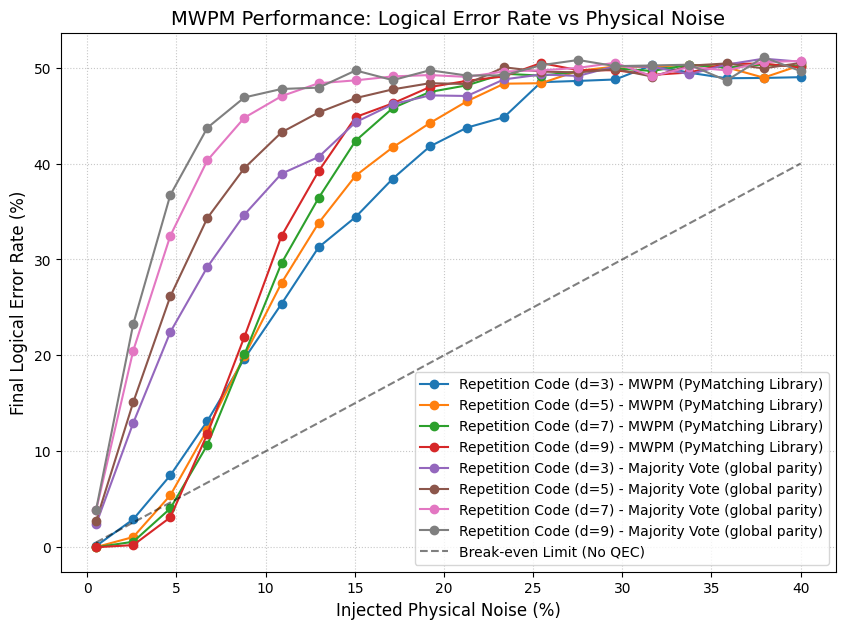

In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import math

# Import the main simulation function
from basic_repetition_code_simulation import simulate_repetition_code
from decoders import MWPMLibraryDecoder, RepetitionMajorityVoteDecoder

# Experiment configuration parameters
distances = [3, 5, 7, 9]
num_shots = 10000
min_error_rate = 0.005
max_error_rate = 0.15
num_samples = 20
min_error_rate = 0.005
max_error_rate = 0.4
error_steps = 10


# Create an array of different physical noise levels
physical_noise_levels = np.linspace(min_error_rate, max_error_rate, num_samples)

# Initialize the plot before the loops
plt.figure(figsize=(10, 7))

print("Running multi-distance simulations... (This may take a minute)")

# Sweep through each distance topology
for decoder in [MWPMLibraryDecoder, RepetitionMajorityVoteDecoder]:
    print(f"Evaluating decoder: {decoder.name()}...")
    for distance in distances:
        logical_error_rates = []
        print(f"Simulating distance d={distance}...")
        
        # Sweep through the noise levels for the current distance
        for noise in physical_noise_levels:
            total_ler = 0
            states = ["0", "1"]
            shots_per_state = num_shots // len(states)
            for state in states:
                ler = simulate_repetition_code(
                    distance=distance,
                    rounds = math.ceil(distance/2),
                    state=state,
                    before_round_data_depolarization_noise = noise, 
                    after_clifford_depolarization_noise = noise, 
                    before_measure_flip_probability_noise = noise*1.5,
                    num_shots=shots_per_state,
                    decoder_class=decoder
                )
                total_ler += ler * (shots_per_state / num_shots)
            logical_error_rates.append(total_ler)

        # Plot the curve for the current distance immediately after its loop finishes
        plt.plot(
            physical_noise_levels * 100, 
            logical_error_rates, 
            marker='o', 
            linestyle='-', 
            label=f'Repetition Code (d={distance}) - {decoder.name()}'
        )

# Plot the break-even line
plt.plot(
    [min_error_rate * 100, max_error_rate * 100], 
    [min_error_rate * 100, max_error_rate * 100],
    linestyle='--', 
    color='black', 
    alpha=0.5, 
    label='Break-even Limit (No QEC)'
)

# Format the graph
plt.title("Repetition Code performance by distance and decoder", fontsize=14)
plt.xlabel("Injected Physical Noise (%)", fontsize=12)
plt.ylabel("Final Logical Error Rate (%)", fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# Display the final composite chart
plt.show()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Running multi-distance simulations... (This may take a minute)
Evaluating decoder: MWPM (PyMatching Library)...
Simulating shor code...
Evaluating decoder: Shor 9-Qubit Majority Vote...
Simulating shor code...


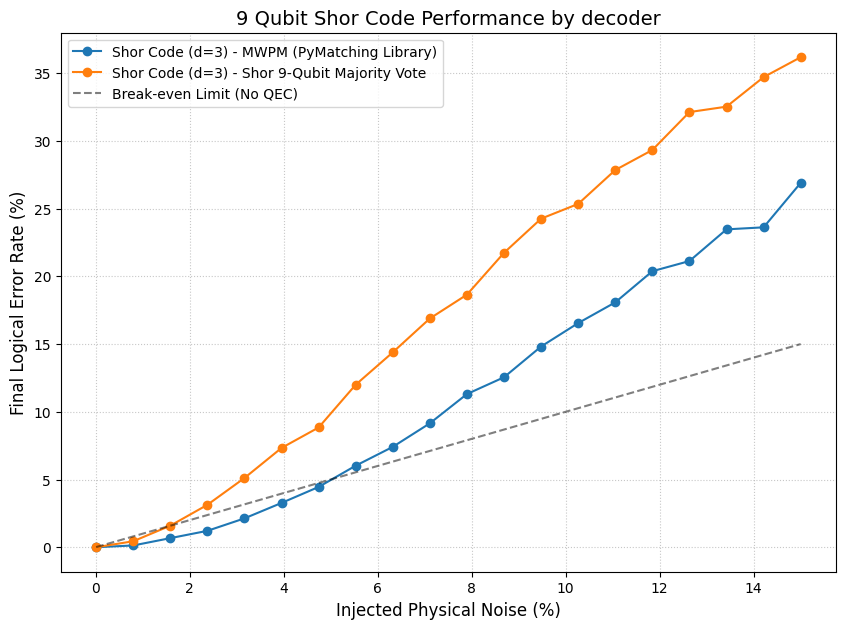

In [8]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import math

# Import the main simulation function
from shor_9_code_simulation import simulate_shor_code
from decoders import MWPMLibraryDecoder, Shor9MajorityVoteDecoder

# Experiment configuration parameters
distance = 3 # This is fixed for the shor code, we set it here to calculate rounds
num_shots = 10000
min_error_rate = 0.0001
max_error_rate = 0.15
num_samples = 20

# Create an array of different physical noise levels
physical_noise_levels = np.linspace(min_error_rate, max_error_rate, num_samples)

# Initialize the plot before the loops
plt.figure(figsize=(10, 7))

print("Running multi-distance simulations... (This may take a minute)")

# Sweep through each distance topology
for decoder in [MWPMLibraryDecoder,Shor9MajorityVoteDecoder]:
    print(f"Evaluating decoder: {decoder.name()}...")

    logical_error_rates = []
    print(f"Simulating shor code...")
    
    # Sweep through the noise levels for the current distance
    for noise in physical_noise_levels:
        total_ler = 0
        states = ["0", "1", "+", "-"]
        shots_per_state = num_shots // len(states)
        for state in states:
            ler = simulate_shor_code(
                rounds = 2,
                state=state,
                before_round_data_depolarization_noise = noise, 
                after_clifford_depolarization_noise = 0*noise, 
                before_measure_flip_probability_noise = 0*noise*1.5,
                num_shots=shots_per_state,
                decoder_class=decoder
            )
            total_ler += ler * (shots_per_state / num_shots)
        logical_error_rates.append(total_ler)

    # Plot the curve for the current distance immediately after its loop finishes
    plt.plot(
        physical_noise_levels * 100, 
        logical_error_rates, 
        marker='o', 
        linestyle='-', 
        label=f'Shor Code (d={distance}) - {decoder.name()}'
    )

# Plot the break-even line
plt.plot(
    [min_error_rate * 100, max_error_rate * 100], 
    [min_error_rate * 100, max_error_rate * 100],
    linestyle='--', 
    color='black', 
    alpha=0.5, 
    label='Break-even Limit (No QEC)'
)

# Format the graph
plt.title("9 Qubit Shor Code Performance by decoder", fontsize=14)
plt.xlabel("Injected Physical Noise (%)", fontsize=12)
plt.ylabel("Final Logical Error Rate (%)", fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# Display the final composite chart
plt.show()
